# Bitcoin Data, Exploratory Analysis, and Time-Series Diagnostics

## Role
This notebook characterises the Bitcoin daily target series before any forecasting model is trained or evaluated. It establishes the data-quality, stationarity, distributional, dependence, volatility, and tail-risk evidence that later Bitcoin notebooks rely on to justify model choice, regime-conditional robustness analysis, and uncertainty evaluation.

## Inputs
`data/bitcoin/btcusd_1-min_data.csv` (local, Git-ignored, minute-level BTC/USD OHLCV).

## Outputs
Diagnostic evidence only: data-quality audit tables, descriptive statistics, stationarity test results, autocorrelation/seasonality evidence, and diagnostic figures. This notebook does not create or overwrite any authoritative forecasting artifact.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.bitcoin_pipeline import *

RUN_GENERATION = False
PROMOTE_TO_AUTHORITATIVE = False

## 1. Objective and Research Question

This exploratory analysis answers questions that later modelling and trustworthiness decisions depend on:

- Is the Bitcoin price level stationary?
- Are log returns more suitable for modelling than raw prices?
- How volatile and heavy-tailed is the series?
- Is there evidence of short-memory or weekly dependence?
- Are extreme movements and changing variance large enough to justify regime-conditional evaluation?
- What characteristics of the series should influence model choice and later trustworthiness analysis?

> Characterise the target series' non-stationarity, volatility, dependence, tail behaviour, and temporal instability so that downstream modelling choices and trustworthiness evaluations are empirically justified rather than assumed.

Findings from this notebook inform classical-model design, log-return neural formulations, Transformer target choice, volatility/movement robustness analysis, and temporal-stability analysis in later notebooks. This EDA does not itself prove forecastability: it characterises the series so that later evaluation decisions have an empirical basis. No forecasting model is trained or evaluated in this notebook.

## 2. Data Provenance

| Item | Value |
|---|---|
| Dataset | BTC/USD minute-level OHLCV |
| Local file | `data/bitcoin/btcusd_1-min_data.csv` |
| Timestamp convention | Unix seconds, converted to UTC |
| Original frequency | 1 minute |
| Research frequency | Daily |
| Daily target | Close |
| Raw date range | 2012-01-01 00:01 UTC to 2026-07-07 01:57 UTC (verified local record; re-confirmed by the load in Section 3) |
| Daily date range | 2012-01-01 to 2026-07-07, 5,302 daily rows (re-confirmed by the load in Section 3) |
| Raw row count | 7,633,557 (verified local record; re-confirmed by the load in Section 3) |
| Access/source status | Local file only. Repository code and notebooks identify it as BTC/USD minute-level OHLCV with columns `Timestamp`, `Open`, `High`, `Low`, `Close`, `Volume`. No documented download procedure or collection method is recorded. |
| Licence status | Not verified. The repository contains no licence record for this file. |
| Known provenance limitation | The original provider, download URL, and licence are unverified and must be confirmed by the researcher before redistribution or external release. The filename alone is not sufficient evidence from which to infer a publisher. |

This evidence is exactly as documented in `data/bitcoin/README.md`; nothing about the original provider, exchange, collection method, or licence is inferred beyond what that record states.

## 3. Data Loading and Canonical Preparation

The canonical pipeline is unchanged: sort the minute-level source chronologically, convert timestamps to UTC, resample to UTC calendar days (Open=first, High=max, Low=min, Close=last, Volume=sum), drop incomplete daily rows, and take daily `Close` as the forecast target. This uses the existing `src.data_loader.load_bitcoin_data` and `src.preprocessing.prepare_daily_bitcoin_data` helpers via `src.bitcoin_pipeline.load_bitcoin_target`; no second, competing preprocessing implementation is introduced here.

In [2]:
# Load the canonical target and chronological split.
daily, target = load_bitcoin_target(ROOT)
train, test = canonical_split(target)

# Load the minute-level source directly as well, for the Section 4 data-quality audit.
raw = load_bitcoin_data(ROOT / 'data' / 'bitcoin' / 'btcusd_1-min_data.csv')

summary = pd.DataFrame({
    'Value': [
        len(raw),
        raw.Timestamp.min(),
        raw.Timestamp.max(),
        len(daily),
        int(daily.isna().sum().sum()),
        target.index.min(),
        target.index.max(),
    ]
}, index=[
    'Minute rows', 'Minute start', 'Minute end', 'UTC daily rows',
    'Daily missing values', 'Target start', 'Target end',
])
summary

,Value
Minute rows,7633557
Minute start,2012-01-01 00:01:00+00:00
Minute end,2026-07-07 01:57:00+00:00
UTC daily rows,5302
Daily missing values,0
Target start,2012-01-01 00:00:00+00:00
Target end,2026-07-07 00:00:00+00:00


Open=first, High=max, Low=min, Close=last, Volume=sum in UTC calendar days. The target is the last available Close in each UTC date. This load reproduces the Section 2 Data Provenance figures exactly: raw row count, raw date range, and daily row count all match.

## 4. Data Quality Audit

In [3]:
# One combined data-quality audit table: raw/timestamp, daily series,
# calendar continuity, and the partial-final-day check.
quality_checks = []

ohlcv_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
quality_checks += [
    ('Raw / timestamp', 'Raw row count', len(raw)),
    ('Raw / timestamp', 'Duplicate timestamps', int(raw['Timestamp'].duplicated().sum())),
    ('Raw / timestamp', 'Timestamps sorted (monotonic increasing)', bool(raw['Timestamp'].is_monotonic_increasing)),
    ('Raw / timestamp', 'Malformed timestamps (unparsed)', int(raw['Timestamp'].isna().sum())),
    ('Raw / timestamp', 'Nonfinite OHLCV cells', int((~np.isfinite(raw[ohlcv_cols])).to_numpy().sum())),
]

quality_checks += [
    ('Daily series', 'Daily row count', len(target)),
    ('Daily series', 'Duplicate daily dates', int(target.index.duplicated().sum())),
    ('Daily series', 'Missing target values', int(target.isna().sum())),
    ('Daily series', 'Nonfinite target values', int((~np.isfinite(target)).sum())),
    ('Daily series', 'Zero Close values', int((target == 0).sum())),
    ('Daily series', 'Negative Close values', int((target < 0).sum())),
    ('Daily series', 'Minimum Close (USD)', float(target.min())),
    ('Daily series', 'Maximum Close (USD)', float(target.max())),
]

full_calendar = pd.date_range(target.index.min(), target.index.max(), freq='D', tz='UTC')
missing_dates = full_calendar.difference(target.index)
quality_checks += [
    ('Calendar continuity', 'Expected calendar days', len(full_calendar)),
    ('Calendar continuity', 'Actual daily observations', len(target)),
    ('Calendar continuity', 'Missing calendar dates', len(missing_dates)),
]

final_minute_timestamp = raw['Timestamp'].max()
final_day_complete = final_minute_timestamp.time() == pd.Timestamp('23:59:00').time()
quality_checks += [
    ('Partial final day', 'Final minute-level timestamp (UTC)', str(final_minute_timestamp)),
    ('Partial final day', 'Final UTC day complete?', final_day_complete),
]

quality_audit = pd.DataFrame(quality_checks, columns=['Category', 'Metric', 'Value']).set_index(['Category', 'Metric'])
quality_audit

Value
Category            Metric                                                             
Raw / timestamp     Raw row count                                               7633557
                    Duplicate timestamps                                              0
                    Timestamps sorted (monotonic increasing)                       True
                    Malformed timestamps (unparsed)                                   0
                    Nonfinite OHLCV cells                                             0
Daily series        Daily row count                                                5302
                    Duplicate daily dates                                             0
                    Missing target values                                             0
                    Nonfinite target values                                           0
                    Zero Close values                                                 0
                    Negative Close values                                             0
                    Minimum Close (USD)                                            4.23
                    Maximum Close (USD)                                        124728.0
Calendar continuity Expected calendar days                                         5302
                    Actual daily observations                                      5302
                    Missing calendar dates                                            0
Partial final day   Final minute-level timestamp (UTC)        2026-07-07 01:57:00+00:00
                    Final UTC day complete?                                       False

`Missing calendar days = 0` — no gaps to list or impute. This is also structurally guaranteed: `load_bitcoin_target` raises `ValueError` if the target index is not a complete, unique daily sequence, so a successful load is itself evidence of full calendar continuity.

`Final UTC day complete? No` — the last minute-level observation is at 2026-07-07 01:57 UTC, so the final daily row aggregates only the first ~1 hour 57 minutes of that UTC calendar day rather than a full 24-hour session. This partial row is retained rather than dropped, to preserve the frozen `bitcoin-v1` test window (see Limitations, Section 16).

## 5. Descriptive Statistics

In [4]:
from scipy import stats

# Daily log return, used throughout the remainder of this notebook.
log_return = np.log(target / target.shift(1)).rename('Log Return')


def describe_series(s):
    clean = s.dropna()
    q = clean.quantile([0.01, 0.05, 0.25, 0.75, 0.95, 0.99])
    return pd.Series({
        'Count': int(clean.count()),
        'Mean': clean.mean(),
        'Median': clean.median(),
        'Std Dev': clean.std(),
        'Min': clean.min(),
        '1%': q[0.01],
        '5%': q[0.05],
        '25%': q[0.25],
        '75%': q[0.75],
        '95%': q[0.95],
        '99%': q[0.99],
        'Max': clean.max(),
        'Skewness': stats.skew(clean),
        'Excess Kurtosis (Fisher)': stats.kurtosis(clean, fisher=True),
    })


descriptive_stats = pd.DataFrame({
    'Daily Close (USD)': describe_series(target),
    'Daily Log Return': describe_series(log_return),
}).round(6)
descriptive_stats

,Daily Close (USD),Daily Log Return
Count,5302.000000,5301.000000
Mean,23527.629898,0.001784
Median,8039.070000,0.001332
Std Dev,31329.448169,0.041003
Min,4.230000,-0.663948
1%,4.980100,-0.115960
5%,11.030500,-0.058749
25%,456.647500,-0.012602
75%,38345.492500,0.016985
95%,96123.350000,0.060391


Price-level statistics for daily Close are strongly shaped by Bitcoin's multi-order-of-magnitude appreciation over 2012-2026 (minimum \$4.23, maximum \$124,728): the mean (\$23,528) sits well above the median (\$8,039), and skewness is positive and large (approximately 1.41). These figures describe a long-term level shift, not a stable price regime, and should not be read as a stationary "typical price."

Daily log returns are approximately centred near zero (mean approximately 0.0018, median approximately 0.0013) but are **not** well-described as normal: skewness is negative (approximately -1.30, a heavier downside tail) and excess kurtosis is large and positive (approximately 25.1), indicating substantially heavier tails than a Gaussian distribution. This is examined further with a Q-Q plot in Section 10.

## 6. Temporal Coverage and Split Definition

In [5]:
split_table = pd.DataFrame({
    'Start': [train.index.min(), test.index.min()],
    'End': [train.index.max(), test.index.max()],
    'Observations': [len(train), len(test)],
}, index=['Training', 'Final Test'])
split_table['Share'] = (split_table['Observations'] / len(target)).round(4)
split_table

,Start,End,Observations,Share
Training,2012-01-01 00:00:00+00:00,2023-08-11 00:00:00+00:00,4241,0.7999
Final Test,2023-08-12 00:00:00+00:00,2026-07-07 00:00:00+00:00,1061,0.2001


The split is **chronological**, not random: the first 80% of daily observations (4,241 days, 2012-01-01 to 2023-08-11) form the training partition, and the final 20% (1,061 days, 2023-08-12 to 2026-07-07) form the frozen final test. A random split would let a model implicitly see information from dates after the ones it is being asked to forecast, which is not available in any real deployment setting; chronological ordering is the only split consistent with the past-only forecasting protocol used throughout this project.

> All final model comparisons use the frozen chronological test period.

## 7. Raw Series Visualisation

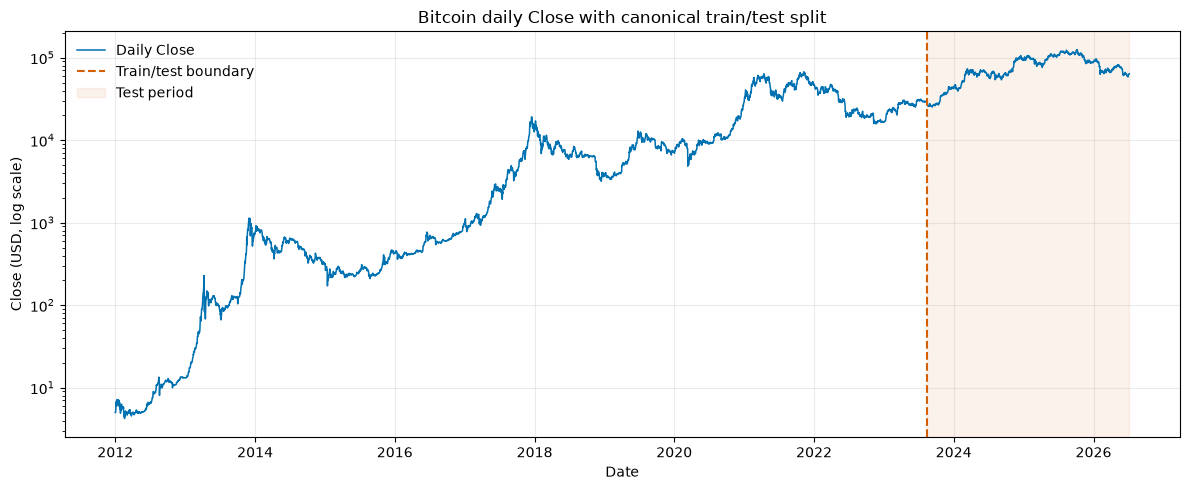

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(target.index, target, color='#0072B2', linewidth=1.1, label='Daily Close')
ax.axvline(test.index.min(), color='#D55E00', linestyle='--', linewidth=1.5, label='Train/test boundary')
ax.axvspan(test.index.min(), target.index.max(), color='#D55E00', alpha=0.08, label='Test period')
ax.set_yscale('log')
ax.set(title='Bitcoin daily Close with canonical train/test split', xlabel='Date', ylabel='Close (USD, log scale)')
ax.grid(alpha=0.25)
ax.legend(frameon=False)
fig.tight_layout()
from pathlib import Path
_figure_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "figures").is_dir())
_figure_dir = _figure_root / "figures" / "bitcoin"
_figure_dir.mkdir(parents=True, exist_ok=True)
_figure_path = _figure_dir / "bitcoin_price_history.png"
plt.gcf().savefig(_figure_path, dpi=300, bbox_inches="tight")
plt.show()

The logarithmic y-axis keeps the full 2012-2026 history legible despite Bitcoin's price growing by more than four orders of magnitude. The shaded region marks the already-fixed final test period (Section 6); it is a visual annotation, not a new split calculation. The evolving price scale itself is descriptive evidence of strong non-stationarity in levels — no causal trend is implied or claimed.

## 8. Stationarity Analysis

Two complementary tests are applied to (A) the daily Close level and (B) the daily log-return series, each computed over the **full observed series**. This is descriptive methodology evidence about the completed dataset, not a test-only calculation (see the guardrail in Section 14).

- **Augmented Dickey-Fuller (ADF)**: H0 = the series has a unit root (is non-stationary). Rejecting H0 supports stationarity.
- **KPSS**: H0 = the series is stationary around the specified deterministic component. Rejecting H0 supports non-stationarity.

Both tests use a constant-only deterministic specification (`regression='c'`): a constant level, with no linear time-trend term. This is appropriate for the log-return series, which is expected to fluctuate around a roughly constant mean, and is used identically for the Close level for direct comparability between the two tests; it deliberately does not fit a trend line to a series already expected to be non-stationary in levels.

In [7]:
import warnings
from statsmodels.tsa.stattools import adfuller, kpss


def adf_row(series, label):
    stat, pvalue, used_lag, nobs, crit, *_ = adfuller(series.dropna(), regression='c', autolag='AIC')
    return {
        'Series': label, 'Test': 'ADF', 'Statistic': stat, 'p-value': pvalue,
        'Critical value / interpretation': f"5% CV = {crit['5%']:.4f}",
        'Conclusion': 'Reject H0 (stationary)' if pvalue < 0.05 else 'Fail to reject H0 (non-stationary)',
    }


def kpss_row(series, label):
    # KPSS p-values are interpolated from a fixed table and are capped at the
    # table bounds outside [0.01, 0.10]; the resulting InterpolationWarning is
    # expected here and does not indicate a broken calculation.
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        stat, pvalue, used_lag, crit = kpss(series.dropna(), regression='c', nlags='auto')
    return {
        'Series': label, 'Test': 'KPSS', 'Statistic': stat, 'p-value': pvalue,
        'Critical value / interpretation': f"5% CV = {crit['5%']:.3f}",
        'Conclusion': 'Reject H0 (non-stationary)' if pvalue < 0.05 else 'Fail to reject H0 (stationary)',
    }


stationarity_results = pd.DataFrame([
    adf_row(target, 'Daily Close'),
    kpss_row(target, 'Daily Close'),
    adf_row(log_return, 'Daily Log Return'),
    kpss_row(log_return, 'Daily Log Return'),
])
stationarity_results

,Series,Test,Statistic,p-value,Critical value / interpretation,Conclusion
0,Daily Close,ADF,-1.217133,6.661825e-01,5% CV = -2.8621,Fail to reject H0 (non-stationary)
1,Daily Close,KPSS,8.576621,1.000000e-02,5% CV = 0.463,Reject H0 (non-stationary)
2,Daily Log Return,ADF,-13.503080,2.951004e-25,5% CV = -2.8621,Reject H0 (stationary)
3,Daily Log Return,KPSS,0.457018,5.257824e-02,5% CV = 0.463,Fail to reject H0 (stationary)


For the **Close level**, ADF fails to reject the unit-root null (p approximately 0.67) and KPSS rejects the stationarity null (p <= 0.01): the two tests jointly agree that daily Close is non-stationary.

For **log returns**, ADF strongly rejects the unit-root null (p approximately 3e-25) and KPSS fails to reject the stationarity null, though only narrowly (p approximately 0.053, just above the conventional 5% threshold). The two tests point the same direction — evidence for stationarity — but the KPSS margin is not wide, so this is treated as supportive rather than conclusive evidence. Together, this provides evidence for modelling transformations based on returns rather than raw price levels.

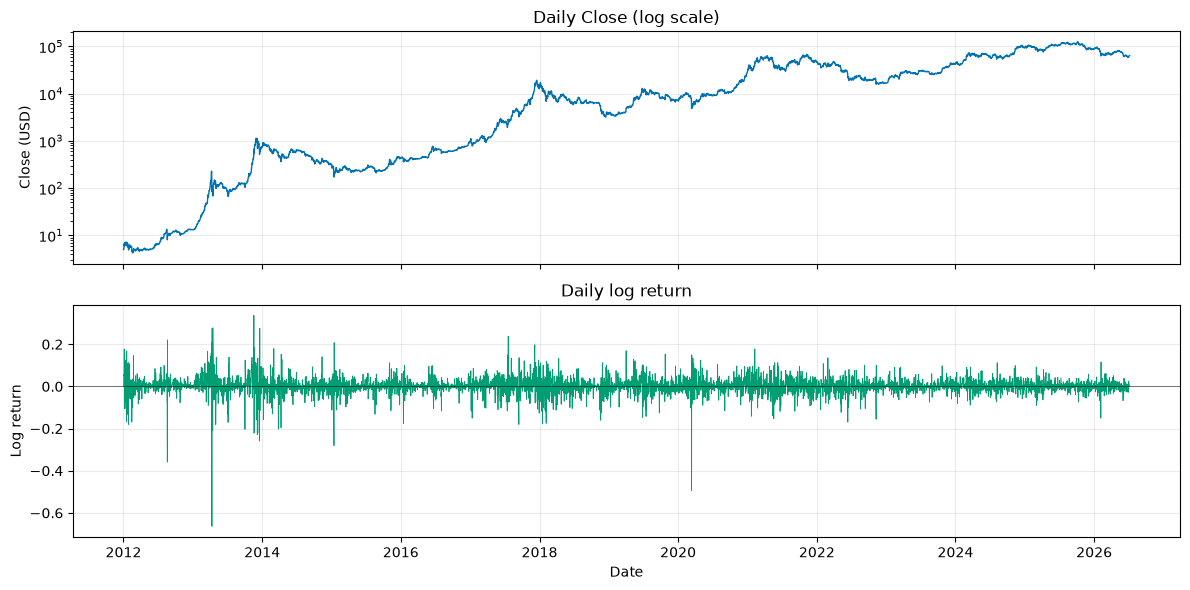

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(target.index, target, color='#0072B2', linewidth=1.0)
axes[0].set_yscale('log')
axes[0].set(title='Daily Close (log scale)', ylabel='Close (USD)')
axes[1].plot(log_return.index, log_return, color='#009E73', linewidth=0.6)
axes[1].axhline(0, color='black', linewidth=0.6, alpha=0.6)
axes[1].set(title='Daily log return', xlabel='Date', ylabel='Log return')
for ax in axes:
    ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

## 9. Returns and Volatility Analysis

Daily log return is defined as `log(P_t / P_(t-1))`; the 30-day rolling standard deviation of log returns is the project's existing volatility diagnostic and is retained unchanged here.

In [9]:
eda = pd.DataFrame({'Close': target, 'Log Return': log_return})
eda['30-Day Volatility'] = eda['Log Return'].rolling(30).std()
eda.tail()

,Close,Log Return,30-Day Volatility
Timestamp,,,
2026-07-03 00:00:00+00:00,62522.46,0.016829,0.019967
2026-07-04 00:00:00+00:00,63086.18,0.008976,0.020038
2026-07-05 00:00:00+00:00,63587.06,0.007908,0.018272
2026-07-06 00:00:00+00:00,64000.10,0.006475,0.018276
2026-07-07 00:00:00+00:00,63902.77,-0.001522,0.016819


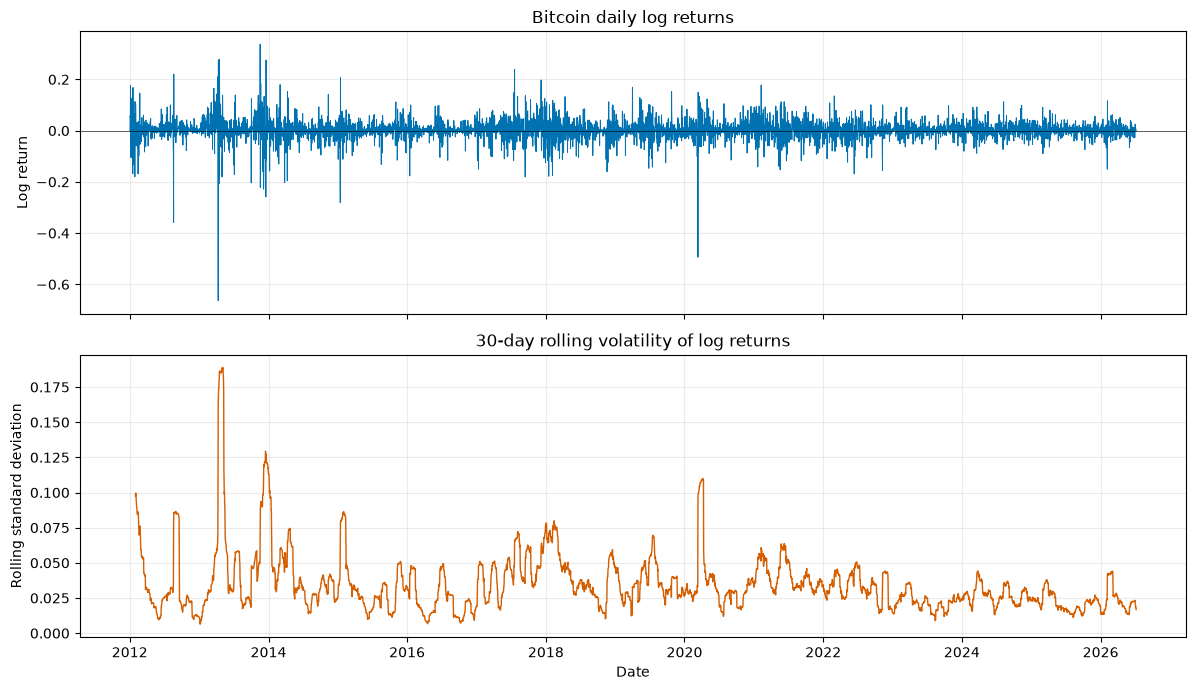

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(eda.index, eda['Log Return'], color='#0072B2', linewidth=0.7)
axes[0].axhline(0, color='black', linewidth=0.7, alpha=0.6)
axes[0].set(title='Bitcoin daily log returns', ylabel='Log return')
axes[1].plot(eda.index, eda['30-Day Volatility'], color='#D55E00', linewidth=1.0)
axes[1].set(title='30-day rolling volatility of log returns', xlabel='Date', ylabel='Rolling standard deviation')
for ax in axes:
    ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

Rolling volatility varies substantially over time rather than sitting near a constant level: quiet multi-month periods alternate with sharply elevated-volatility periods, consistent with volatility clustering (periods of large moves tend to be followed by further large moves). This changing variance is presented here only as motivation; no volatility regime thresholds are defined in this notebook — those are defined later from training data only (Section 14).

## 10. Distributional Analysis

The normal curve below is a visual reference fitted to the observed log-return mean and standard deviation; it is not a distributional assumption used anywhere in the forecasting pipeline.

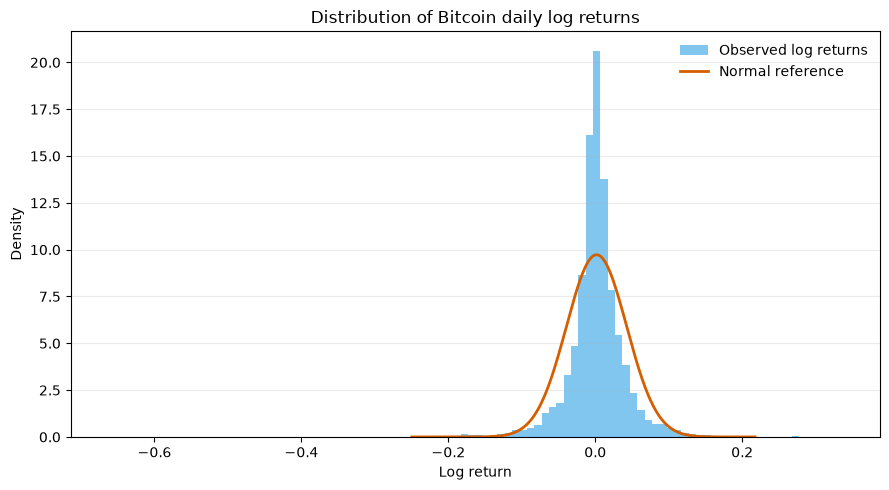

In [11]:
returns = log_return.dropna()
x = np.linspace(returns.quantile(0.001), returns.quantile(0.999), 500)
normal_density = stats.norm.pdf(x, loc=returns.mean(), scale=returns.std(ddof=1))

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(returns, bins=100, density=True, color='#56B4E9', alpha=0.75, label='Observed log returns')
ax.plot(x, normal_density, color='#D55E00', linewidth=2, label='Normal reference')
ax.set(title='Distribution of Bitcoin daily log returns', xlabel='Log return', ylabel='Density')
ax.grid(axis='y', alpha=0.25)
ax.legend(frameon=False)
fig.tight_layout()
from pathlib import Path
_figure_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "figures").is_dir())
_figure_dir = _figure_root / "figures" / "bitcoin"
_figure_dir.mkdir(parents=True, exist_ok=True)
_figure_path = _figure_dir / "bitcoin_log_return_distribution.png"
plt.gcf().savefig(_figure_path, dpi=300, bbox_inches="tight")
plt.show()

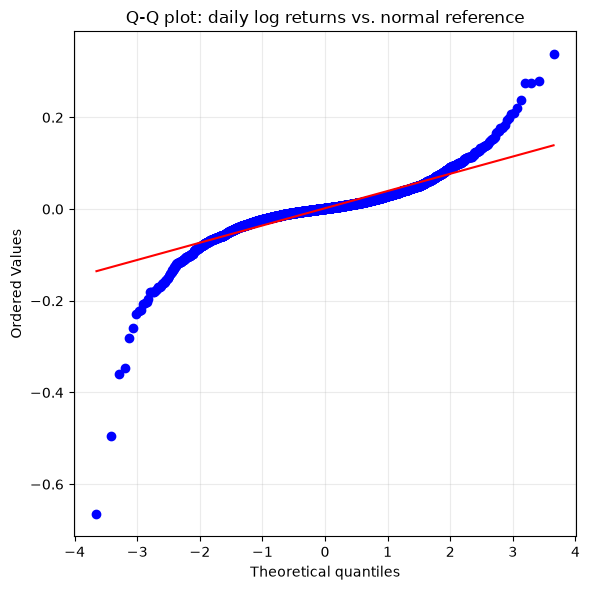

In [12]:
fig, ax = plt.subplots(figsize=(6, 6))
stats.probplot(returns, dist='norm', plot=ax)
ax.set_title('Q-Q plot: daily log returns vs. normal reference')
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

The central distribution may appear approximately symmetric, but the Q-Q plot and excess kurtosis (approximately 25.1, Section 5) indicate substantial tail departures from the Gaussian reference: points diverge from the reference line at both extremes, consistent with the heavier-than-normal tails already identified numerically. Combined with the negative skewness (approximately -1.30), the evidence supports treating daily Bitcoin log returns as heavy-tailed rather than approximately normal.

## 11. Autocorrelation and Seasonality Analysis

Computed on **log returns**, not raw price levels, since only the (approximately) stationary transformation makes autocorrelation coefficients interpretable. The lag range is 30 days, with a separate focus on the weekly lag (lag 7).

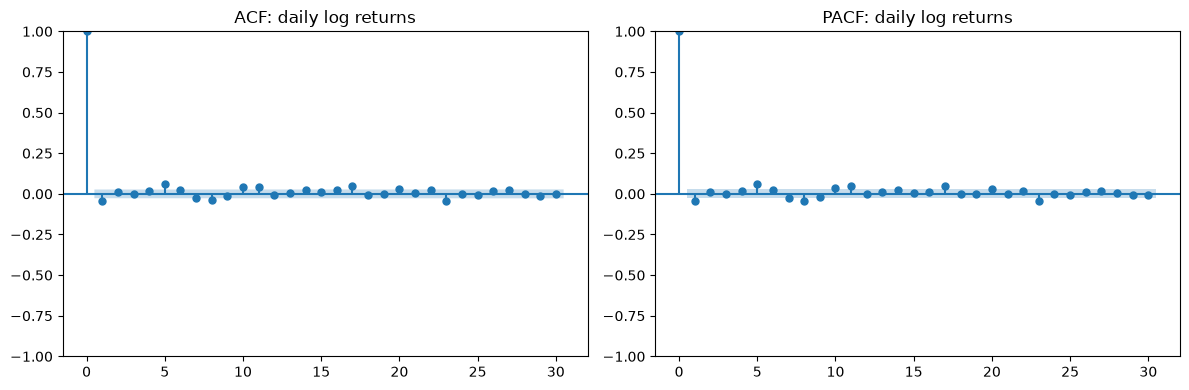

In [13]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(returns, lags=30, ax=axes[0])
axes[0].set_title('ACF: daily log returns')
plot_pacf(returns, lags=30, ax=axes[1], method='ywm')
axes[1].set_title('PACF: daily log returns')
fig.tight_layout()
from pathlib import Path
_figure_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "figures").is_dir())
_figure_dir = _figure_root / "figures" / "bitcoin"
_figure_dir.mkdir(parents=True, exist_ok=True)
_figure_path = _figure_dir / "bitcoin_return_acf_pacf.png"
plt.gcf().savefig(_figure_path, dpi=300, bbox_inches="tight")
plt.show()

In [14]:
from statsmodels.tsa.stattools import acf as acf_values
from statsmodels.tsa.seasonal import STL

# Reproduced from the current canonical series, not hard-coded.
acf_full = acf_values(returns, nlags=30, fft=False, adjusted=False)
lag7_acf = acf_full[7]
white_noise_bound = 1.96 / np.sqrt(len(returns))

stl = STL(returns, period=7, robust=True).fit()
seasonal_strength = max(0.0, 1 - np.var(stl.resid) / np.var(stl.resid + stl.seasonal))

weekly_evidence = pd.Series({
    'Lag-7 ACF': lag7_acf,
    'Approx. 95% white-noise bound (+/-)': white_noise_bound,
    'Weekly STL strength': seasonal_strength,
}, name='Weekly seasonality evidence').to_frame()
weekly_evidence

,Weekly seasonality evidence
Lag-7 ACF,-0.023323
Approx. 95% white-noise bound (+/-),0.026920
Weekly STL strength,0.069923


The reproduced lag-7 ACF (approximately -0.0233) sits inside the approximate 95% white-noise band (+/-0.0269) — indistinguishable from zero at conventional significance — and this closely reproduces the value previously reported in `02_Bitcoin_Classical_Baselines.ipynb` (lag-7 ACF approximately -0.023409, bound approximately +/-0.026920; the small difference is consistent with minor library-version floating-point differences, not a methodology change). The weekly STL seasonal strength (approximately 0.0699, on a 0-1 scale) reproduces the earlier value exactly and is low: only a small share of the residual variance is attributable to a 7-day seasonal component. Together, lag-7 dependence is weak and no strong weekly seasonal component is supported.

> Downstream Notebook 02 should treat this EDA result as the empirical basis for excluding a weekly SARIMA specification from the final Bitcoin benchmark.

## 12. Extreme Daily Movements

In [15]:
extreme_moves = (
    eda.dropna(subset=['Log Return'])
    .assign(**{
        'Absolute Log Return': lambda d: d['Log Return'].abs(),
        'Direction': lambda d: np.where(d['Log Return'] >= 0, 'Up', 'Down'),
    })
    .nlargest(12, 'Absolute Log Return')
    [['Close', 'Log Return', 'Absolute Log Return', 'Direction']]
)
extreme_moves.index.name = 'Date'
extreme_moves.round(6)

,Close,Log Return,Absolute Log Return,Direction
Date,,,,
2013-04-11 00:00:00+00:00,83.40,-0.663948,0.663948,Down
2020-03-12 00:00:00+00:00,4841.67,-0.493969,0.493969,Down
2012-08-19 00:00:00+00:00,8.06,-0.358906,0.358906,Down
2013-04-10 00:00:00+00:00,162.00,-0.346126,0.346126,Down
2013-11-18 00:00:00+00:00,669.01,0.337486,0.337486,Up
2015-01-14 00:00:00+00:00,171.41,-0.280892,0.280892,Down
2013-04-17 00:00:00+00:00,89.98,0.278757,0.278757,Up
2013-04-12 00:00:00+00:00,109.90,0.275923,0.275923,Up
2013-12-19 00:00:00+00:00,685.00,0.275590,0.275590,Up


These are the 12 largest daily absolute log-return moves in the observed history, sorted by magnitude. This is descriptive evidence only, with no external news or causal explanation attached to any date. Their combined effect is that average-case accuracy metrics can conceal how a model behaves on a small number of days that matter disproportionately for real decisions — this motivates the later **Regime-Conditional Robustness** analysis, without defining any regime threshold here.

## 13. Structural Change and Regime Preview

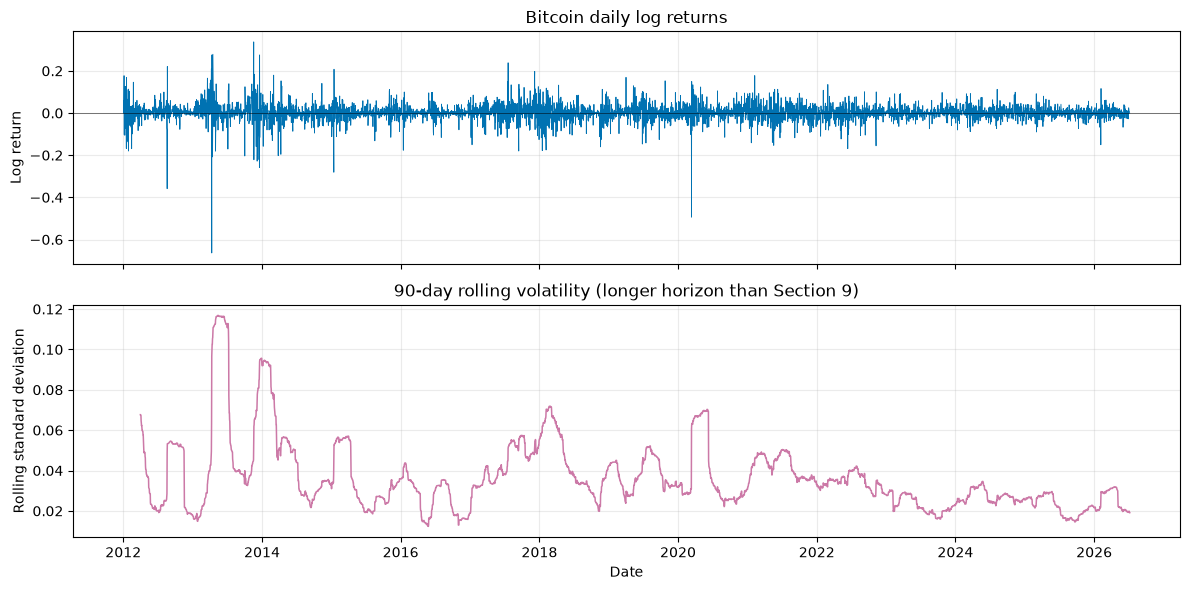

In [16]:
# A longer 90-day window than Section 9's 30-day volatility, to reveal
# slower-moving local regime structure without repeating the same figure.
eda['90-Day Volatility'] = eda['Log Return'].rolling(90).std()

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(eda.index, eda['Log Return'], color='#0072B2', linewidth=0.6)
axes[0].axhline(0, color='black', linewidth=0.6, alpha=0.6)
axes[0].set(title='Bitcoin daily log returns', ylabel='Log return')
axes[1].plot(eda.index, eda['90-Day Volatility'], color='#CC79A7', linewidth=1.1)
axes[1].set(title='90-day rolling volatility (longer horizon than Section 9)', xlabel='Date', ylabel='Rolling standard deviation')
for ax in axes:
    ax.grid(alpha=0.25)
fig.tight_layout()
from pathlib import Path
_figure_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "figures").is_dir())
_figure_dir = _figure_root / "figures" / "bitcoin"
_figure_dir.mkdir(parents=True, exist_ok=True)
_figure_path = _figure_dir / "bitcoin_returns_and_long_run_volatility.png"
plt.gcf().savefig(_figure_path, dpi=300, bbox_inches="tight")
plt.show()

> The visual evidence indicates substantial variation in local volatility over time, motivating later regime-conditional evaluation.

No formal structural-break test is conducted here, so this is described as visual evidence of local variation rather than as a formal "regime shift." Final regime thresholds are defined later from training-only data (Section 14).

## 14. Leakage and Methodology Guardrail

This notebook distinguishes two different uses of data.

### EDA
Full-series descriptive plots and statistics (Sections 5-13) may legitimately describe the **completed, already-observed** dataset — including the final test period — because they characterise what the data looks like, not how a forecasting model is fit, selected, or calibrated. Examples above that intentionally use the full series: descriptive statistics, the stationarity tests, distributional analysis, ACF/PACF/STL seasonality evidence, and the extreme-move table.

### Model selection / threshold definition
Any quantity that influences a final modelling decision — calibration, robustness thresholds, hyperparameter selection, or a forecast itself — must be derived from training/development information only.

Concretely:

- The final test targets are never used to fit forecasting models.
- Final regime thresholds (volatility/movement robustness) are defined later using **training data only**.
- Final uncertainty calibration is not fitted from final-test residuals.
- This EDA does not alter the frozen final-test observations in any authoritative artifact.

It would be incorrect to claim every descriptive statistic above uses training data only — several intentionally describe the whole observed series. The distinction that matters is between *describing* the completed dataset (this notebook) and *fitting or selecting* against it (later notebooks, which restrict themselves to training/development information for any decision that affects a forecast).

## 15. Key Findings

- Bitcoin price levels show strong non-stationarity: ADF fails to reject a unit root and KPSS rejects stationarity for daily Close (Section 8).
- Log returns are substantially more stationary than raw prices: ADF strongly rejects the unit-root null, and KPSS does not reject stationarity at 5% (albeit narrowly) (Section 8).
- Daily returns exhibit changing volatility, consistent with volatility clustering rather than constant variance (Sections 9 and 13).
- Return tails deviate materially from the Gaussian reference: excess kurtosis approximately 25.1, skewness approximately -1.30, and the Q-Q plot shows tail departures from normality (Sections 5 and 10).
- Weekly seasonal dependence is weak and unsupported: lag-7 ACF falls inside the approximate white-noise band and weekly STL strength is low (approximately 0.07) (Section 11).
- Extreme daily movements are material: the largest observed daily log returns exceed +/-30-66%, dwarfing typical daily variation (Section 12).
- Together, persistence-dominated near-random-walk behaviour, non-stationarity in levels, heavy tails, and time-varying volatility motivate strong persistence/statistical baselines, return-based neural model formulations, regime-conditional robustness analysis, and uncertainty evaluation in later notebooks.

No forecasting model has been evaluated in this notebook, so no forecasting-performance conclusion is drawn here.

## 16. Limitations

- The final UTC date (2026-07-07) is a partial daily observation, covering only the first approximately 1 hour 57 minutes of that calendar day (Section 4).
- The original data provider, download URL, and licence are unverified; this must be confirmed before redistribution or external release (Section 2).
- The study uses a single Bitcoin asset (BTC/USD); findings are not shown to generalise to other cryptoassets.
- The observed history (2012-2026) spans materially different market conditions, liquidity regimes, and participant bases; descriptive statistics pool across all of them.
- Descriptive statistical dependence (or its absence) does not imply predictability; this EDA characterises the series but does not evaluate any forecasting model.
- Possible foundation-model pretraining overlap cannot later be ruled out, because the data window overlaps public historical periods; this is a limitation of later foundation-model validity (zero-shot Chronos/TimesFM evaluation), not a limitation of the Bitcoin data or the diagnostics in this notebook.

## 17. Next Notebook

Next: `02_Bitcoin_Classical_Baselines.ipynb`

Notebook 02 uses this EDA's evidence to establish the persistence baseline, moving-average baseline, rolling exponential-smoothing models, and ARIMA, together with protocol-fairness evidence for the rolling one-step forecasting task. It should cite this notebook's weekly-seasonality finding (Section 11) — that weekly dependence is weak and unsupported — as the empirical basis for excluding a weekly SARIMA specification, rather than treating weekly seasonality as an assumed property.